In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

import polars as pl
import matplotlib.pyplot as plt
from tqdm import tqdm

from lmf import db

In [2]:
def X_y(df, label, num_ap=1229):
    """
    Given a polars dataframe df, return the feature matrix X and target vector y.
    The features are the first num_ap coefficients a_p of the L-series.
    The target is the column specified by label.
    """
    columns_ = [f"a_{p:04d}" for p in Primes()[:num_ap]]
    X = df.select(columns_)
    y = df.select(label)
    return X, y

In [3]:
max_N = 10^5
num_ap = 1229
df = pl.read_csv(f"ec_data_N{max_N}_ap{num_ap}.csv")
cols_100 = ["isog_label", "wa1", "wa2", "wa3", "conductor", "rank"] + [f"a_{p:04d}" for p in Primes()[:25]]
cols_1000 = ["isog_label", "wa1", "wa2", "wa3", "conductor", "rank"] + [f"a_{p:04d}" for p in Primes()[:168]]
df_p100 = df.select(cols_100)
df_p1000 = df.select(cols_1000)

In [4]:
df_p100.head()

isog_label,wa1,wa2,wa3,conductor,rank,a_0002,a_0003,a_0005,a_0007,a_0011,a_0013,a_0017,a_0019,a_0023,a_0029,a_0031,a_0037,a_0041,a_0043,a_0047,a_0053,a_0059,a_0061,a_0067,a_0071,a_0073,a_0079,a_0083,a_0089,a_0097
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""11.a""",0,-1,1,11,0,-2,-1,1,-2,1,4,-2,0,-1,0,7,3,-8,-6,8,-6,5,12,-7,-3,4,-10,-6,15,-7
"""14.a""",1,0,1,14,0,-1,-2,0,1,0,-4,6,2,0,-6,-4,2,6,8,-12,6,-6,8,-4,0,2,8,-6,-6,-10
"""15.a""",1,1,1,15,0,-1,-1,1,0,-4,-2,2,4,0,-2,0,-10,10,4,8,-10,-4,-2,12,-8,10,0,12,-6,2
"""17.a""",1,-1,1,17,0,-1,0,-2,4,0,-2,1,-4,4,6,4,-2,-6,4,0,6,-12,-10,4,-4,-6,12,-4,10,2
"""19.a""",0,1,1,19,0,0,-2,3,-1,3,-4,-3,1,0,6,-4,2,-6,-1,-3,12,-6,-1,-4,6,-7,8,12,12,8


### Predict $w_1$

Predict $w_1$ (`wa1`) using all $a_p$'s.

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     43829
           1     1.0000    1.0000    1.0000     43617

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[43829     0]
 [    0 43617]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     43829
           1     1.0000    1.0000    1.0000     43617

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[43829     0]
 [    0 43617]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     43829
           1     1.0000    1.0000    1.0000     43617

    accuracy                         1.0000     87446
   macro avg     1.0000    1.000

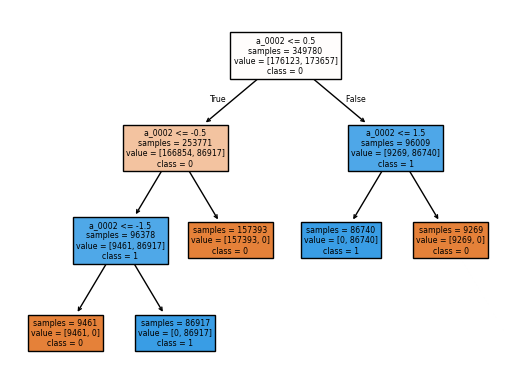

In [5]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    X, y = X_y(df_, "wa1", num_ap=num_ap)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    if num_ap == 25:
        plot_tree(
            model,
            filled=True,
            feature_names=X.columns,
            class_names=[str(c) for c in model.classes_],
            impurity=False,
        )
        plt.savefig(f"figs/w1_num_ap_{num_ap}.png", dpi=600)

Predict $w_1$ using all $a_p$'s except $a_2$.

In [6]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_ = [f"a_{p:04d}" for p in Primes()[1:num_ap]]
    X = df.select(columns_)
    y = df.select("wa1")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

              precision    recall  f1-score   support

           0     0.5114    0.5136    0.5125     43829
           1     0.5091    0.5069    0.5080     43617

    accuracy                         0.5103     87446
   macro avg     0.5103    0.5103    0.5103     87446
weighted avg     0.5103    0.5103    0.5103     87446

Confusion matrix
[[22512 21317]
 [21508 22109]]
              precision    recall  f1-score   support

           0     0.5612    0.5614    0.5613     43829
           1     0.5591    0.5590    0.5591     43617

    accuracy                         0.5602     87446
   macro avg     0.5602    0.5602    0.5602     87446
weighted avg     0.5602    0.5602    0.5602     87446

Confusion matrix
[[24606 19223]
 [19236 24381]]
              precision    recall  f1-score   support

           0     0.6243    0.6267    0.6255     43829
           1     0.6235    0.6211    0.6223     43617

    accuracy                         0.6239     87446
   macro avg     0.6239    0.623

### Predict $w_2$

Predict $w_2$ (`wa2`) using all $a_p$'s.

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]
              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]
              precision    recall  f1-score   support

          -1     1.00

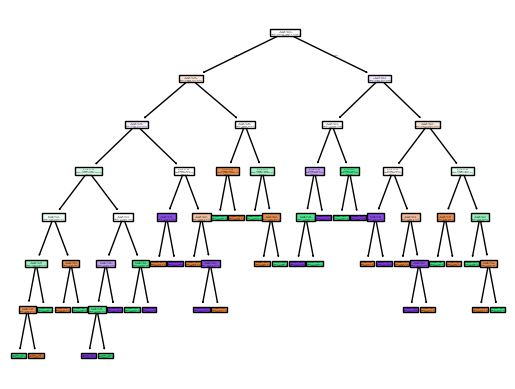

In [7]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    X, y = X_y(df_, "wa2", num_ap=num_ap)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    if num_ap == 25:
        plot_tree(
            model,
            filled=True,
            feature_names=X.columns,
            class_names=[str(c) for c in model.classes_],
            impurity=False,
        )
        plt.savefig(f"figs/w2_num_ap_{num_ap}.png", dpi=600)

Predict $w_2$ using $a_2 \pmod{2}$ and $a_3 \pmod{3}$

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]


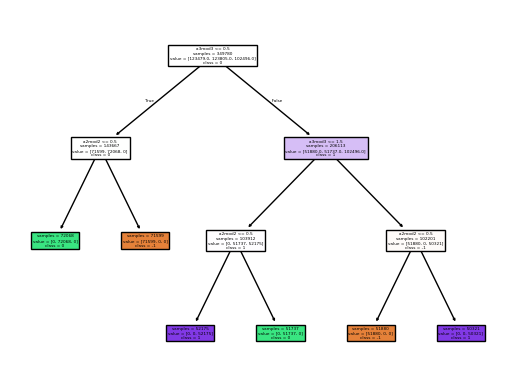

In [8]:
df_p100_new = df_p100.with_columns(
    (pl.col("a_0002") % 2).alias("a2mod2"),
    (pl.col("a_0003") % 3).alias("a3mod3"),
).drop("a_0002").drop("a_0003")

X = df_p100_new.select(["a2mod2", "a3mod3"])
y = df_p100_new.select("wa2")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
clr = classification_report(y_test, y_pred, digits=4)
print(clr)
print("Confusion matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    impurity=False,
)
plt.savefig(f"figs/w2_a2mod2_a3mod3.png", dpi=600)

Predict $w_2$ using one-hot encoding of $a_2 \pmod{2}$ and $a_3 \pmod{3}$

              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000     30829
           0     1.0000    1.0000    1.0000     31189
           1     1.0000    1.0000    1.0000     25428

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[30829     0     0]
 [    0 31189     0]
 [    0     0 25428]]


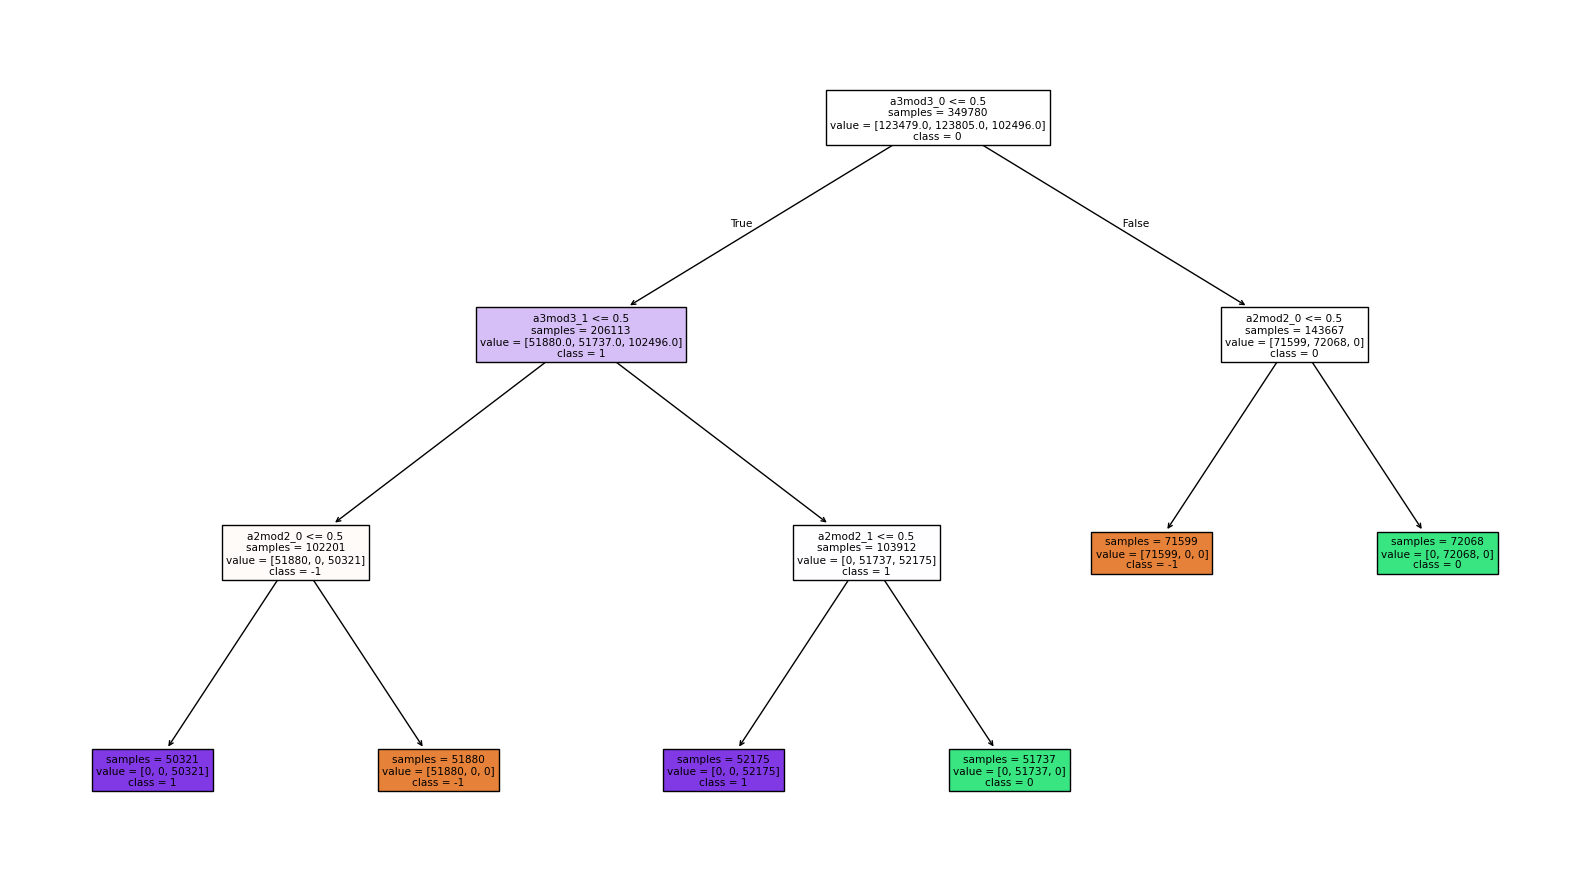

In [9]:
df_p100_new_ohe = df_p100_new.with_columns(
    (pl.col("a2mod2") == 0).cast(pl.Int8).alias("a2mod2_0"),
    (pl.col("a2mod2") == 1).cast(pl.Int8).alias("a2mod2_1"),
    (pl.col("a3mod3") == 0).cast(pl.Int8).alias("a3mod3_0"),
    (pl.col("a3mod3") == 1).cast(pl.Int8).alias("a3mod3_1"),
    (pl.col("a3mod3") == 2).cast(pl.Int8).alias("a3mod3_2"),
)

one_hot_columns = ["a2mod2_0", "a2mod2_1", "a3mod3_0", "a3mod3_1", "a3mod3_2"]
X = df_p100_new_ohe.select(one_hot_columns)
y = df_p100_new_ohe.select("wa2")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

clr = classification_report(y_test, y_pred, digits=4)
print(clr)
print("Confusion matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(16, 9))
plot_tree(
    model,
    filled=True,
    feature_names=one_hot_columns,
    class_names=[str(c) for c in model.classes_],
    impurity=False,
)
plt.tight_layout()
plt.savefig("figs/w2_a2mod2_a3mod3_onehot.png", dpi=600)

Lookup table for $w_2$ based on $(a_2, a_3)$

In [10]:
df_wa2_m1 = df.filter(pl.col("wa2") == -1)
df_wa2_z = df.filter(pl.col("wa2") == 0)
df_wa2_p1 = df.filter(pl.col("wa2") == 1)

with pl.Config(tbl_rows=-1):
    print("wa2 = -1")
    print(df_wa2_m1.unique(subset=["a_0002", "a_0003"]).select(["a_0002", "a_0003"]))

    print("wa2 = 0")
    print(df_wa2_z.unique(subset=["a_0002", "a_0003"]).select(["a_0002", "a_0003"]))

    print("wa2 = 1")
    print(df_wa2_p1.unique(subset=["a_0002", "a_0003"]).select(["a_0002", "a_0003"]))

wa2 = -1
shape: (12, 2)
┌────────┬────────┐
│ a_0002 ┆ a_0003 │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ -1     ┆ 3      │
│ 2      ┆ 2      │
│ -2     ┆ 2      │
│ 1      ┆ 0      │
│ -1     ┆ 0      │
│ -2     ┆ -1     │
│ 1      ┆ 3      │
│ -1     ┆ -3     │
│ 1      ┆ -3     │
│ 2      ┆ -1     │
│ 0      ┆ 2      │
│ 0      ┆ -1     │
└────────┴────────┘
wa2 = 0
shape: (13, 2)
┌────────┬────────┐
│ a_0002 ┆ a_0003 │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ -2     ┆ 0      │
│ 2      ┆ 3      │
│ 2      ┆ -3     │
│ 1      ┆ 1      │
│ 1      ┆ -2     │
│ -2     ┆ -3     │
│ -1     ┆ 1      │
│ -1     ┆ -2     │
│ 2      ┆ 0      │
│ 0      ┆ 0      │
│ -2     ┆ 3      │
│ 0      ┆ 3      │
│ 0      ┆ -3     │
└────────┴────────┘
wa2 = 1
shape: (10, 2)
┌────────┬────────┐
│ a_0002 ┆ a_0003 │
│ ---    ┆ ---    │
│ i64    ┆ i64    │
╞════════╪════════╡
│ 0      ┆ 1      │
│ -1     ┆ 2      │
│ 2      ┆ 1      │
│ 2      ┆ -2     │
│ -2     ┆

Predict $w_2$ using all $a_p$'s except $a_2$.

In [11]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_wo2 = [f"a_{p:04d}" for p in Primes()[1:num_ap]]
    X = df_.select(columns_wo2)
    y = df_.select("wa2")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

              precision    recall  f1-score   support

          -1     0.5137    0.5157    0.5147     30829
           0     0.5132    0.5116    0.5124     31189
           1     0.4987    0.4982    0.4985     25428

    accuracy                         0.5092     87446
   macro avg     0.5085    0.5085    0.5085     87446
weighted avg     0.5092    0.5092    0.5092     87446

Confusion matrix
[[15898  8680  6251]
 [ 8747 15957  6485]
 [ 6305  6454 12669]]
              precision    recall  f1-score   support

          -1     0.5355    0.5351    0.5353     30829
           0     0.5373    0.5363    0.5368     31189
           1     0.4970    0.4985    0.4978     25428

    accuracy                         0.5249     87446
   macro avg     0.5233    0.5233    0.5233     87446
weighted avg     0.5250    0.5249    0.5249     87446

Confusion matrix
[[16498  8015  6316]
 [ 7949 16728  6512]
 [ 6362  6389 12677]]
              precision    recall  f1-score   support

          -1     0.55

Predict $w_2$ using all $a_p$'s except $a_3$.

In [12]:

# for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
for df_, num_ap in [(df_p100, 25)]:
    columns_wo3 = ["a_0002"] + [f"a_{p:04d}" for p in Primes()[2:num_ap]]
    X = df_.select(columns_wo3)
    y = df_.select("wa2")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

              precision    recall  f1-score   support

          -1     0.3622    0.3608    0.3615     30829
           0     0.3759    0.3731    0.3745     31189
           1     0.2917    0.2957    0.2937     25428

    accuracy                         0.3463     87446
   macro avg     0.3433    0.3432    0.3432     87446
weighted avg     0.3466    0.3463    0.3464     87446

Confusion matrix
[[11123 10454  9252]
 [10547 11638  9004]
 [ 9040  8869  7519]]


Predict $w_2$ (`wa2`) using all $a_p$'s except $a_2$ and $a_3$.

In [13]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_wo23 = [f"a_{p:04d}" for p in Primes()[2:num_ap]]

    X = df_.select(columns_wo23)
    y = df_.select("wa2")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

              precision    recall  f1-score   support

          -1     0.3515    0.3483    0.3499     30829
           0     0.3581    0.3548    0.3565     31189
           1     0.2934    0.2998    0.2966     25428

    accuracy                         0.3366     87446
   macro avg     0.3343    0.3343    0.3343     87446
weighted avg     0.3369    0.3366    0.3367     87446

Confusion matrix
[[10739 10926  9164]
 [10925 11067  9197]
 [ 8891  8913  7624]]
              precision    recall  f1-score   support

          -1     0.3532    0.3504    0.3518     30829
           0     0.3613    0.3599    0.3606     31189
           1     0.2918    0.2960    0.2939     25428

    accuracy                         0.3380     87446
   macro avg     0.3354    0.3354    0.3354     87446
weighted avg     0.3382    0.3380    0.3381     87446

Confusion matrix
[[10802 10938  9089]
 [10784 11225  9180]
 [ 8995  8907  7526]]
              precision    recall  f1-score   support

          -1     0.34

### Predict $w_3$

Predict $w_3$ (`wa3`) using all $a_p$'s.

In [14]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    X, y = X_y(df_, "wa3", num_ap=num_ap)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

              precision    recall  f1-score   support

           0     0.8019    0.7889    0.7953     56623
           1     0.6234    0.6419    0.6325     30823

    accuracy                         0.7371     87446
   macro avg     0.7126    0.7154    0.7139     87446
weighted avg     0.7390    0.7371    0.7379     87446

Confusion matrix
[[44672 11951]
 [11039 19784]]
              precision    recall  f1-score   support

           0     0.8117    0.8065    0.8091     56623
           1     0.6487    0.6564    0.6525     30823

    accuracy                         0.7536     87446
   macro avg     0.7302    0.7314    0.7308     87446
weighted avg     0.7543    0.7536    0.7539     87446

Confusion matrix
[[45668 10955]
 [10592 20231]]
              precision    recall  f1-score   support

           0     0.8211    0.8181    0.8196     56623
           1     0.6681    0.6725    0.6703     30823

    accuracy                         0.7668     87446
   macro avg     0.7446    0.745

Predict $w_3$ using all $a_p$'s and $w_1$ and $w_2$.

In [15]:
for df_, num_ap in [(df_p100, 25), (df_p1000, 168), (df, 1229)]:
    columns_w12 = ["wa1", "wa2"] + [f"a_{p:04d}" for p in Primes()[:num_ap]]
    X = df_.select(columns_w12)
    y = df_.select("wa3")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
    model = DecisionTreeClassifier(random_state=42, max_depth=10)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clr = classification_report(y_test, y_pred, digits=4)
    print(clr)
    print("Confusion matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

              precision    recall  f1-score   support

           0     0.8499    0.9145    0.8810     56623
           1     0.8174    0.7034    0.7561     30823

    accuracy                         0.8401     87446
   macro avg     0.8337    0.8089    0.8186     87446
weighted avg     0.8385    0.8401    0.8370     87446

Confusion matrix
[[51781  4842]
 [ 9143 21680]]
              precision    recall  f1-score   support

           0     0.8498    0.9138    0.8806     56623
           1     0.8162    0.7033    0.7555     30823

    accuracy                         0.8396     87446
   macro avg     0.8330    0.8085    0.8181     87446
weighted avg     0.8379    0.8396    0.8365     87446

Confusion matrix
[[51740  4883]
 [ 9145 21678]]
              precision    recall  f1-score   support

           0     0.8491    0.9135    0.8801     56623
           1     0.8154    0.7017    0.7543     30823

    accuracy                         0.8389     87446
   macro avg     0.8322    0.807

In [16]:
# If a_2 = -2 or a_2 = 2, then wa3 = 1.
df_p100.filter(
    (pl.col("a_0002") == -2) | (pl.col("a_0002") == 2)
)["wa3"].unique()

wa3
i64
1


Predict $w_3$ (`wa3`) with $w_2$ (`wa2`), $a_2$ (`a_00002`), and $N \pmod{2}$ (`Nmod2`).

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     56623
           1     1.0000    1.0000    1.0000     30823

    accuracy                         1.0000     87446
   macro avg     1.0000    1.0000    1.0000     87446
weighted avg     1.0000    1.0000    1.0000     87446

Confusion matrix
[[56623     0]
 [    0 30823]]


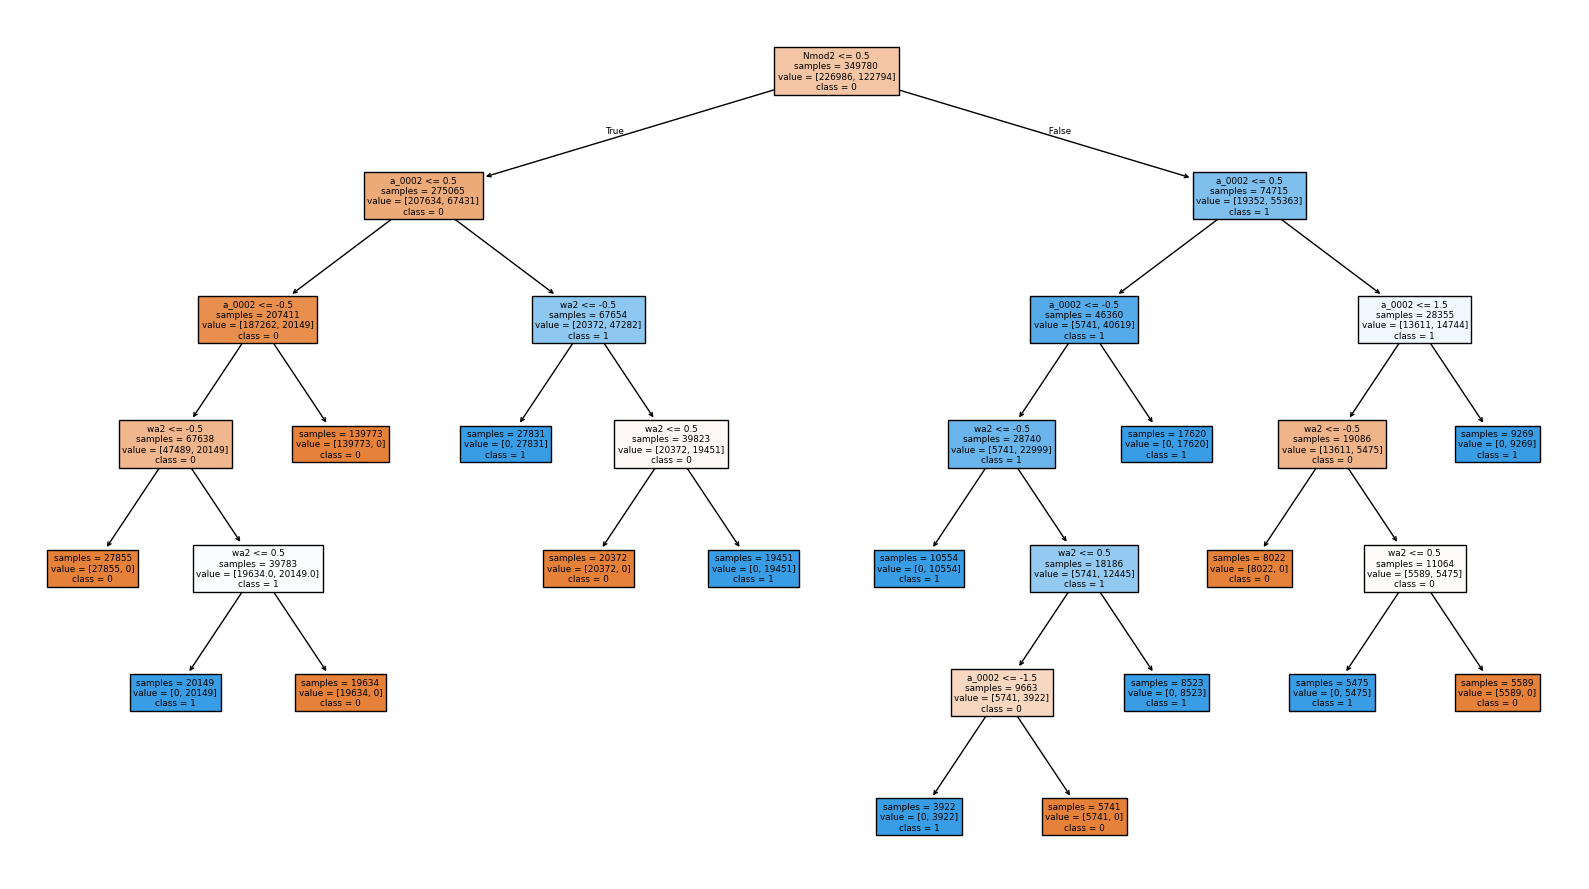

In [17]:
Nmod2_col = (pl.col("conductor") % 2).alias("Nmod2")
df_p100_N2 = df_p100.with_columns(Nmod2_col)

new_columns = ["a_0002", "wa2", "Nmod2"]
X = df_p100_N2.select(new_columns)
y = df_p100_N2.select("wa3")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=float(0.2), random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

clr = classification_report(y_test, y_pred, digits=4)
print(clr)
print("Confusion matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(16, 9))
plot_tree(
    model,
    filled=True,
    feature_names=new_columns,
    class_names=[str(c) for c in model.classes_],
    impurity=False,
)
plt.tight_layout()
plt.savefig("figs/w3_a2_w2_Nmod2.png", dpi=1200)
